# Low-Risk Anomaly 프로젝트 — 데이터 수집

## 전체 파이프라인
1. **유니버스 구성**: S&P500 역사적 구성 종목 (생존편향 완화)
2. **가격 데이터**: yfinance (일별 OHLCV)
3. **피처 계산**: vol, beta, mcap, 월별 수익률
4. **월별 패널**: `monthly_panel.csv` 저장

## 수집 변수 (필요한 것만)
| 변수 | 설명 | 용도 |
|------|------|------|
| `ret_1m` | 월별 수익률 | 포트폴리오 성과, Σ 추정 |
| `vol_20d` | 20일 실현변동성 (연환산) | 변동성 예측 타겟 |
| `vol_60d` | 60일 실현변동성 | EDA |
| `vol_252d` | 252일 실현변동성 | 저위험 분류 기준 |
| `beta_252d` | 252일 CAPM 베타 (vs SPY) | 저위험 분류 기준 |
| `log_mcap` | 로그 시가총액 | P 행렬 가중치 (BL) |
| `gics_sector` | GICS 섹터 | 섹터 분석 |
| `fwd_ret_1m` | 다음달 수익률 (타겟) | 성과 검증 |

## 설계 결정사항
- **생존편향**: Wikipedia S&P500 변경 히스토리 역방향 재구성 (한계: 2004~2010 일부 누락 가능)
- **중복 티커**: GOOGL/GOOG → GOOGL만 사용, BRK.A/BRK.B → BRK.B만 사용
- **Unknown 섹터**: 유니버스에 포함 (indmom 미사용이므로 문제 없음)

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import pickle
import time
import warnings
import platform
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore')

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
DATA_DIR.mkdir(parents=True, exist_ok=True)

# PRICE_START : 2004-01-01 → rolling(252) 워밍업 + ret_1m 첫 행 확보
# PRICE_END   : 2026-03-31 → 2025-12 fwd_ret_1m 계산을 위해 1분기 더 수집
# PANEL_START : 2005-01-01 → 금융위기(2008) 포함을 위해 1년 앞당김
# PANEL_END   : 2025-12-31 → 실제 분석 패널 종료
PRICE_START = '2004-01-01'
PRICE_END   = '2026-03-31'
PANEL_START = '2004-01-01'
PANEL_END   = '2025-12-31'

print(f'데이터 경로: {DATA_DIR}')
print(f'가격 수집 기간: {PRICE_START} ~ {PRICE_END}')
print(f'패널 기간:     {PANEL_START} ~ {PANEL_END}')
print(f'→ TRAIN_WINDOW=36개월 시 2008-01부터 예측 가능 (금융위기 포함)')

데이터 경로: /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/김윤서/low_risk/data
가격 수집 기간: 2004-01-01 ~ 2026-03-31
패널 기간:     2004-01-01 ~ 2025-12-31
→ TRAIN_WINDOW=36개월 시 2008-01부터 예측 가능 (금융위기 포함)


# 1. S&P500 유니버스 구성 (생존편향 완화)

## 핵심 아이디어
- Wikipedia S&P500 현재 구성 + 변경 히스토리 → **역방향 재구성**
- 매월 "그 시점에 실제로 편입되어 있던 종목"만 패널에 포함
- 상장폐지/편출된 종목도 포함 → 생존편향 완화

## GOOGL/GOOG 중복 문제
- Alphabet은 GOOGL(Class A)과 GOOG(Class C) 두 종목이 모두 S&P500에 편입
- 같은 회사를 두 번 포함하면 공분산 행렬 추정에 왜곡 발생
- **해결**: GOOGL만 사용, GOOG 제거
- 같은 이유로 BRK.A → BRK.B만 사용

In [2]:
import requests
from bs4 import BeautifulSoup

DUPLICATE_DROP = {'GOOG', 'BRK.A'}

URL     = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
HEADERS = {'User-Agent': 'Mozilla/5.0 (compatible; research-bot/1.0)'}

def fetch_sp500_tables():
    """Wikipedia S&P500 페이지에서 wikitable 2개 반환"""
    resp = requests.get(URL, headers=HEADERS, timeout=30)
    resp.raise_for_status()
    soup   = BeautifulSoup(resp.text, 'html.parser')
    tables = soup.find_all('table', {'class': 'wikitable'})
    if len(tables) < 2:
        raise ValueError(f"테이블 {len(tables)}개만 발견 (최소 2개 필요) — Wikipedia 구조 변경 가능성")
    return tables

def parse_current_sp500(table) -> pd.DataFrame:
    df = pd.read_html(str(table))[0]
    df.columns = [c.lower().replace(' ', '_') for c in df.columns]
    col_map = {}
    for c in df.columns:
        if 'symbol' in c or 'ticker' in c: col_map[c] = 'ticker'
        if 'gics_sector' in c or 'sector' in c: col_map[c] = 'gics_sector'
    df = df.rename(columns=col_map)
    df['ticker'] = df['ticker'].str.replace('.', '-', regex=False).str.strip()
    return df[['ticker', 'gics_sector']].drop_duplicates('ticker')

def parse_changes(table) -> pd.DataFrame:
    df = pd.read_html(str(table))[0]
    df.columns = ['_'.join(str(c).lower().split()) for c in df.columns]

    date_col    = next((c for c in df.columns if 'date'  in c), None)
    added_col   = next((c for c in df.columns if 'added'  in c and 'ticker' in c), None)
    removed_col = next((c for c in df.columns if 'remov'  in c and 'ticker' in c), None)

    if date_col is None:
        return pd.DataFrame(columns=['date', 'added', 'removed'])

    df = df[[date_col,
             added_col   if added_col   else df.columns[0],
             removed_col if removed_col else df.columns[0]]].copy()
    df.columns = ['date', 'added', 'removed']
    df['date']    = pd.to_datetime(df['date'], errors='coerce')
    df            = df.dropna(subset=['date'])
    df['added']   = df['added'].astype(str).str.replace('.', '-', regex=False).str.strip()
    df['removed'] = df['removed'].astype(str).str.replace('.', '-', regex=False).str.strip()
    return df

def build_monthly_membership(df_current, df_changes, start, end) -> dict:
    """
    역방향 재구성: 현재 구성에서 시작해 변경 이벤트를 거꾸로 적용
    → 각 월말 시점의 S&P500 구성 종목 반환
    """
    monthly_dates = pd.date_range(start, end, freq='ME')
    current_set   = set(df_current['ticker'].tolist())
    membership    = {}

    for target in sorted(monthly_dates, reverse=True):
        for _, row in df_changes[df_changes['date'] > target].iterrows():
            added   = str(row['added']).strip()
            removed = str(row['removed']).strip()
            if added   and added   != 'nan': current_set.discard(added)
            if removed and removed != 'nan': current_set.add(removed)
        membership[target] = frozenset(current_set)

    return membership

# ── Wikipedia 수집 ──────────────────────────────────────
MEMBERSHIP_PATH = DATA_DIR / 'sp500_membership.pkl'

if MEMBERSHIP_PATH.exists():
    with open(MEMBERSHIP_PATH, 'rb') as f:
        sp500_membership = pickle.load(f)
    print(f"멤버십 히스토리 로드: {len(sp500_membership)}개 월")
else:
    print("Wikipedia에서 S&P500 데이터 수집 중...")
    tables     = fetch_sp500_tables()
    df_current = parse_current_sp500(tables[0])
    df_changes = parse_changes(tables[1])
    print(f"  현재 구성: {len(df_current)}종목 / 변경 이벤트: {len(df_changes)}건")

    sp500_membership = build_monthly_membership(df_current, df_changes, PRICE_START, PRICE_END)
    with open(MEMBERSHIP_PATH, 'wb') as f:
        pickle.dump(sp500_membership, f)
    print(f"  멤버십 생성 완료: {len(sp500_membership)}개 월")

멤버십 히스토리 로드: 267개 월


In [3]:
# ── 전체 유니버스 (역사적으로 한 번이라도 편입된 종목) ────────
UNIVERSE_PATH = DATA_DIR / 'universe.csv'

if UNIVERSE_PATH.exists():
    df_universe = pd.read_csv(UNIVERSE_PATH)
    print(f"유니버스 로드: {len(df_universe)}종목")
else:
    # 현재 구성 재수집 (섹터 매핑용)
    tables     = fetch_sp500_tables()
    df_current = parse_current_sp500(tables[0])
    sector_map = dict(zip(df_current['ticker'], df_current['gics_sector']))

    # 모든 월의 멤버 합집합
    all_tickers = set()
    for members in sp500_membership.values():
        all_tickers.update(members)
    
    # GOOGL/GOOG, BRK.A/BRK.B 중복 제거
    all_tickers -= DUPLICATE_DROP
    print(f"중복 제거 후 유니버스: {len(all_tickers)}종목")
    print(f"  제거된 티커: {DUPLICATE_DROP}")

    # 현재 구성에 없는 역사적 종목 → yfinance로 섹터 보완
    need_sector = all_tickers - set(sector_map.keys())
    print(f"  섹터 미확인 종목 {len(need_sector)}개 → yfinance 조회 중...")
    
    for i, t in enumerate(sorted(need_sector)):
        try:
            info = yf.Ticker(t).info
            sec  = info.get('sector', 'Unknown')
            sector_map[t] = sec
        except:
            sector_map[t] = 'Unknown'
        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{len(need_sector)} 완료")
        time.sleep(0.1)

    df_universe = pd.DataFrame([
        {'ticker': t, 'gics_sector': sector_map.get(t, 'Unknown')}
        for t in sorted(all_tickers)
    ])
    df_universe.to_csv(UNIVERSE_PATH, index=False)
    print(f"\n유니버스 저장: {len(df_universe)}종목")

# Unknown 섹터 현황 확인
n_unknown = (df_universe['gics_sector'] == 'Unknown').sum()
print(f"\n섹터 분포:")
print(df_universe['gics_sector'].value_counts().to_string())
print(f"\n⚠ Unknown 섹터: {n_unknown}개 — 유니버스에는 포함 (indmom 미사용)")

유니버스 로드: 833종목

섹터 분포:
gics_sector
Unknown                   205
Industrials                94
Financials                 76
Information Technology     73
Health Care                58
Consumer Discretionary     48
Real Estate                36
Energy                     35
Consumer Staples           35
Consumer Cyclical          35
Utilities                  32
Communication Services     29
Materials                  26
Financial Services         17
Healthcare                 15
Technology                  9
Basic Materials             6
Consumer Defensive          4

⚠ Unknown 섹터: 205개 — 유니버스에는 포함 (indmom 미사용)


In [4]:
# ── 발행주식수 시계열 수집 (시가총액 계산용) ────────────────
SHARES_PATH = DATA_DIR / 'shares_outstanding.pkl'

if SHARES_PATH.exists():
    with open(SHARES_PATH, 'rb') as f:
        shares_map = pickle.load(f)
    print(f"발행주식수 로드: {len(shares_map)}종목")
else:
    tickers_all = df_universe['ticker'].tolist()
    shares_map  = {}
    print(f"발행주식수 수집 시작: {len(tickers_all)}종목")

    for i, t in enumerate(tickers_all):
        try:
            ts = yf.Ticker(t).get_shares_full(start=PRICE_START)
            if ts is not None and len(ts) > 0:
                shares_map[t] = ts
        except Exception:
            pass
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(tickers_all)} 완료 (수집 성공: {len(shares_map)}개)")
        time.sleep(0.05)

    with open(SHARES_PATH, 'wb') as f:
        pickle.dump(shares_map, f)
    print(f"\n저장 완료: {len(shares_map)}종목 / {len(tickers_all)}종목")

발행주식수 로드: 782종목


# 2. 가격 데이터 수집 (yfinance)

SPY(시장 벤치마크)와 무위험수익률(^IRX: 13주 T-bill)도 함께 수집합니다.

In [5]:
PRICES_PATH = DATA_DIR / 'prices_raw.pkl'
tickers     = df_universe['ticker'].tolist()

if PRICES_PATH.exists():
    prices_raw = pd.read_pickle(PRICES_PATH)
    print(f"가격 데이터 로드: {prices_raw.shape}")
else:
    all_symbols = ['SPY', '^IRX'] + tickers
    print(f"총 {len(all_symbols)}개 티커 다운로드 시작...")

    BATCH = 200
    dfs   = []
    for i in range(0, len(all_symbols), BATCH):
        batch = all_symbols[i:i+BATCH]
        print(f"  배치 {i//BATCH+1}: {batch[0]} ~ {batch[-1]} ({len(batch)}개)")
        df = yf.download(
            batch,
            start=PRICE_START,
            end=PRICE_END,
            auto_adjust=True,
            progress=False
        )
        dfs.append(df)
        time.sleep(1)

    prices_raw = pd.concat(dfs, axis=1)
    prices_raw = prices_raw.loc[:, ~prices_raw.columns.duplicated()]
    prices_raw.to_pickle(PRICES_PATH)
    print(f"\n저장 완료: {prices_raw.shape}")

# Close 가격 추출
if isinstance(prices_raw.columns, pd.MultiIndex):
    close = prices_raw['Close']
else:
    close = prices_raw[['Close']]

# 중복 날짜 제거 (yfinance 배치 다운로드 시 간헐적으로 발생)
n_dup = close.index.duplicated().sum()
if n_dup > 0:
    print(f"중복 날짜 {n_dup}개 제거")
    close = close[~close.index.duplicated(keep='last')]

print(f"\nClose 가격: {close.shape[0]}일 × {close.shape[1]}종목")
print(f"결측치 비율: {close.isna().mean().mean():.1%}")

가격 데이터 로드: (5595, 4340)

Close 가격: 5595일 × 835종목
결측치 비율: 31.8%


In [6]:
# ── 일별 가격 이상값 탐지 ────────────────────────────────
# 하루 사이 가격이 10배 이상 변하는 전환 시점 = yfinance 데이터 오류
# (예: TIE 2010-02: $11 → $20,700, ratio = 1780배)

JUMP_THRESHOLD = 10  # 하루 사이 10배 이상 변화

daily_ratio = close / close.shift(1)  # P_t / P_{t-1}
extreme_mask = (daily_ratio > JUMP_THRESHOLD) | (daily_ratio < 1 / JUMP_THRESHOLD)

# 티커별 이상값 발생 일수
bad_days_per_ticker = extreme_mask.sum()
affected = bad_days_per_ticker[bad_days_per_ticker > 0].sort_values(ascending=False)

print(f"=== 일별 가격 이상값 탐지 (기준: {JUMP_THRESHOLD}배 이상 변화) ===")
print(f"이상값 발생 티커: {len(affected)}개 / {close.shape[1]}개")
print(f"이상값 총 일수:   {int(affected.sum())}일")
print(f"\n[이상값 발생 티커 목록]")
print(affected.to_string())

=== 일별 가격 이상값 탐지 (기준: 10배 이상 변화) ===
이상값 발생 티커: 10개 / 835개
이상값 총 일수:   1106일

[이상값 발생 티커 목록]
Ticker
CBE     656
TIE     197
CFC     120
MEE      85
BMC      24
^IRX     10
CPWR      6
PTV       5
RSH       2
POM       1


In [7]:
# CBE : 12년도 인수
close['RSH'][1500:1600]

Date
2009-12-16      NaN
2009-12-17    34.27
2009-12-18      NaN
2009-12-21      NaN
2009-12-22      NaN
              ...  
2010-05-05      NaN
2010-05-06      NaN
2010-05-07      NaN
2010-05-10    38.02
2010-05-11      NaN
Name: RSH, Length: 100, dtype: float64

In [8]:
# ── 이상값 예시 확인 및 오염 티커 제거 ──────────────────────
# ^IRX(금리)는 성질이 달라 제외, 주식 티커만 처리
stock_affected = affected.drop('^IRX', errors='ignore')

print("=== 이상값 예시 (상위 5개 티커, 각 최대 3건) ===")
for ticker in stock_affected.head(5).index:
    bad_dates = extreme_mask.index[extreme_mask[ticker].values]
    print(f"\n[{ticker}] 이상값 {len(bad_dates)}일")
    print(f"  {'날짜':<12}  {'전일 Close':>12}  {'당일 Close':>12}  {'배율':>7}")
    shown = 0
    for d in bad_dates:
        loc = close.index.get_loc(d)
        if loc == 0:
            continue
        prev_val = close[ticker].iloc[loc - 1]
        curr_val = close[ticker].iloc[loc]
        ratio = curr_val / prev_val if prev_val > 0 else np.nan
        print(f"  {str(d.date()):<12}  {prev_val:>12.2f}  {curr_val:>12.2f}  {ratio:>6.1f}x")
        shown += 1
        if shown >= 3:
            break

# ── 오염 티커 close에서 제거 ─────────────────────────────────
# NaN 마스킹은 점프 시점만 제거해 오염 구간이 남음 → 티커 전체 제거가 더 안전
drop_cols = [c for c in stock_affected.index if c in close.columns]
close = close.drop(columns=drop_cols)

print(f"\n=== 오염 티커 제거 완료 ===")
print(f"제거된 티커 ({len(drop_cols)}개): {drop_cols}")
print(f"close shape: {close.shape}")

=== 이상값 예시 (상위 5개 티커, 각 최대 3건) ===

[CBE] 이상값 656일
  날짜                전일 Close      당일 Close       배율
  2004-01-05            0.52         28.94    55.1x
  2004-01-06           28.94          0.52     0.0x
  2004-01-07            0.52         29.00    55.8x

[TIE] 이상값 197일
  날짜                전일 Close      당일 Close       배율
  2010-02-22           12.06      22900.00  1898.8x
  2010-04-23        28500.00         16.72     0.0x
  2010-04-26           16.72      28600.00  1710.5x

[CFC] 이상값 120일
  날짜                전일 Close      당일 Close       배율
  2006-12-18           83.50          6.85     0.1x
  2006-12-19            6.85         88.00    12.8x
  2006-12-28            8.55         89.50    10.5x

[MEE] 이상값 85일
  날짜                전일 Close      당일 Close       배율
  2008-03-18           10.09          0.11     0.0x
  2008-03-20            0.09          8.50    96.6x
  2008-09-19           23.34          0.30     0.0x

[BMC] 이상값 24일
  날짜                전일 Close      당일 Close       배율
  2

In [9]:
# Adj Close, Close, High, Low, Open, Volume
print(prices_raw.columns.get_level_values(0).unique())

# 전체 NA. 추후 제거
print(prices_raw['Adj Close'].isna().sum())

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Ticker
ABK     5595
ABMD    5595
ACAS    5595
ACE     5595
ADS     5595
        ... 
XEC     5595
XL      5595
XLNX    5595
XTO     5595
YHOO    5595
Length: 165, dtype: int64


In [10]:
# Close
# 가격 데이터 전체 NA 데이터는 추후 제거
sum(prices_raw['Close'].isna().all())

165

# 3. 피처 계산

## 계산 로직 요약
- **수익률**: log return 사용 (덧셈 가능, 정규분포에 가까움)
- **변동성**: rolling std of log return × √252 (연환산)
- **베타**: cov(stock, SPY) / var(SPY), rolling 252일
- **시가총액**: Close × Shares Outstanding — 없으면 Close로 대체 (순위 근사치)
- **무위험수익률**: ^IRX (13주 T-bill, 연율) → 일별 변환

## Look-ahead bias 방지
- 모든 rolling 계산은 과거 데이터만 사용 (forward-looking 없음)
- 타겟 변수 `fwd_ret_1m`은 shift(-1)로 미래 수익률 참조 (타겟 변수 전용)

<Axes: xlabel='SPY', ylabel='Count'>

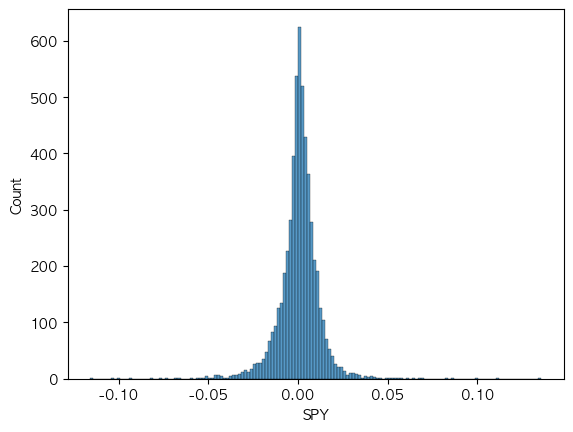

In [11]:
ANN = np.sqrt(252)

# SPY 일별 수익률 (베타 계산용)
spy_close = close['SPY']
spy_lr = np.log(spy_close / spy_close.shift(1))

sns.histplot(spy_lr)

In [12]:
ANN = np.sqrt(252)

spy_close = close['SPY']
spy_lr    = np.log(spy_close / spy_close.shift(1))

rf_annual = close['^IRX'] / 100
rf_daily  = (1 + rf_annual) ** (1/252) - 1

def compute_features(ticker: str, ac: pd.Series) -> pd.DataFrame:
    ac = ac[~ac.index.duplicated(keep='last')]

    df = pd.DataFrame(index=ac.index)

    lr  = np.log(ac / ac.shift(1))
    exc = lr - rf_daily.reindex(ac.index)
    mkt = spy_lr.reindex(ac.index)

    df['vol_21d']  = lr.rolling(21).std() * ANN   # 1개월 거래일 기준 (예측 타겟)
    df['vol_60d']  = lr.rolling(60).std() * ANN
    df['vol_252d'] = lr.rolling(252).std() * ANN

    cov_em          = exc.rolling(252).cov(mkt)
    var_m           = mkt.rolling(252).var()
    df['beta_252d'] = cov_em / var_m

    df['close'] = ac

    if ticker in shares_map:
        shares_ts = shares_map[ticker]
        shares_ts = shares_ts[~shares_ts.index.duplicated(keep='last')]
        if shares_ts.index.tz is not None:
            shares_ts.index = shares_ts.index.tz_localize(None)
        shares_ts = shares_ts.reindex(ac.index).ffill().bfill() # 직전 유효한 값으로 NaN 채우고, 직후 유효한 값으로 NaN 채움
        df['log_mcap'] = np.log((ac * shares_ts).clip(lower=1))
    else:
        df['log_mcap'] = np.log(ac.clip(lower=1e-6))

    r1  = 1 + ac.pct_change()
    df['fwd_ret_1m'] = r1.shift(-1).rolling(21).apply(np.prod, raw=True).shift(-20) - 1

    df['ticker'] = ticker
    return df

print("피처 계산 함수 정의 완료")
print(f"발행주식수 보유 종목: {len(shares_map)}개 / {len(df_universe)}개")
print(f"추가된 피처: vol_21d (21일 롤링, 월별 실현변동성 기준)")

피처 계산 함수 정의 완료
발행주식수 보유 종목: 782개 / 833개
추가된 피처: vol_21d (21일 롤링, 월별 실현변동성 기준)


# 4. 월별 패널 구성

각 종목의 일별 피처를 월말(Month-End)로 리샘플링하고,  
**해당 월에 실제로 S&P500에 편입되어 있던 종목만** 패널에 포함합니다.  
(생존편향 완화의 핵심 단계)

In [ ]:
PANEL_PATH = DATA_DIR / 'monthly_panel.csv'

if PANEL_PATH.exists():
    monthly_df = pd.read_csv(PANEL_PATH, parse_dates=['date'])
    monthly_df = monthly_df.set_index(['date', 'ticker'])
    print(f"패널 로드: {monthly_df.shape}")
else:
    sector_map       = dict(zip(df_universe['ticker'], df_universe['gics_sector']))
    membership_dates = sorted(sp500_membership.keys())

    def get_members_at(date: pd.Timestamp) -> frozenset:
        idx = pd.Series(membership_dates).searchsorted(date, side='right') - 1
        if idx < 0:
            return frozenset()
        return sp500_membership[membership_dates[idx]]

    monthly_panels = []
    valid_tickers  = [t for t in tickers if t in close.columns]
    print(f"피처 계산 시작: {len(valid_tickers)}종목")

    for i, ticker in enumerate(valid_tickers):
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(valid_tickers)} 완료")

        ac = close[ticker].dropna()
        if len(ac) < 252: # 일별 가격 데이터가 252일 미만인 종목을 통째로 제외
            continue

        df = compute_features(ticker, ac)

        df_m = df.resample('ME').last()
        df_m['ticker']      = ticker
        df_m['gics_sector'] = sector_map.get(ticker, 'Unknown')

        df_m = df_m[(df_m.index >= PANEL_START) & (df_m.index <= PANEL_END)]
        monthly_panels.append(df_m)

    monthly_df = pd.concat(monthly_panels)
    monthly_df.index.name = 'date'
    monthly_df = monthly_df.reset_index().set_index(['date', 'ticker'])
    monthly_df = monthly_df.sort_index()

    # ── 생존편향 필터 ────────────────────────────────────
    print("생존편향 필터 적용 중...")
    mask = [(ticker in get_members_at(date))
            for (date, ticker), _ in monthly_df.iterrows()]
    monthly_df = monthly_df[mask]
    print(f"필터 후: {monthly_df.shape[0]}행 ({monthly_df.index.get_level_values('ticker').nunique()}종목)")

    # ── SPY 월별 수익률 ───────────────────────────────────
    spy_monthly = spy_close.resample('ME').last().pct_change().rename('spy_ret')
    monthly_df  = monthly_df.join(spy_monthly, on='date')

    # ── RF 월별 환산 ──────────────────────────────────────
    rf_monthly = rf_daily.resample('ME').apply(lambda x: (1+x).prod()-1).rename('rf_1m')
    monthly_df = monthly_df.join(rf_monthly, on='date')

    # ── ret_1m: 전체 가격 히스토리로 계산 ────────────────
    monthly_close_full = close[valid_tickers].resample('ME').last()
    monthly_ret        = monthly_close_full.pct_change()
    monthly_ret        = monthly_ret.stack(future_stack=True).rename('ret_1m')
    monthly_ret.index.names = ['date', 'ticker']  # yfinance 컬럼명과 monthly_df 인덱스명 통일
    monthly_df = monthly_df.join(monthly_ret)

    monthly_df.to_csv(PANEL_PATH)
    print(f"\n패널 저장: {PANEL_PATH}")

print(f"\n최종 패널: {monthly_df.shape}")
print(f"기간: {monthly_df.index.get_level_values('date').min().date()} ~ {monthly_df.index.get_level_values('date').max().date()}")
print(f"종목 수: {monthly_df.index.get_level_values('ticker').nunique()}")
print(f"\n컬럼:")
print(monthly_df.dtypes)

패널 로드: (108135, 11)

최종 패널: (108135, 11)
기간: 2004-01-31 ~ 2025-12-31
종목 수: 620

컬럼:
vol_21d        float64
vol_60d        float64
vol_252d       float64
beta_252d      float64
close          float64
log_mcap       float64
fwd_ret_1m     float64
gics_sector     object
spy_ret        float64
rf_1m          float64
ret_1m         float64
dtype: object


In [14]:
# ── 패널 기간 검증 ──────────────────────────────────────
actual_start = monthly_df.index.get_level_values('date').min()
actual_end   = monthly_df.index.get_level_values('date').max()

print(f"설정 PANEL_START : {PANEL_START}")
print(f"실제 패널 시작일 : {actual_start.date()}")
print(f"실제 패널 종료일 : {actual_end.date()}")

assert actual_start >= pd.Timestamp(PANEL_START), \
    f"패널 시작일({actual_start.date()})이 PANEL_START({PANEL_START})보다 이름!"
print("시작일 검증 OK")

설정 PANEL_START : 2004-01-01
실제 패널 시작일 : 2004-01-31
실제 패널 종료일 : 2025-12-31
시작일 검증 OK


# 4-1. 데이터 품질 수정: 동시 0값 (yfinance 가격 fill-forward 결함)

## 문제
yfinance는 거래 정지·데이터 누락 구간에서 **직전 가격을 그대로 유지**한다.  
이 경우 `pct_change() = 0.0` → `rolling std = 0.0` → **ret_1m = 0.0, vol_21d = 0.0 동시 발생**.

이 값들은 NaN이 아니므로 기존 NaN 필터를 통과한다.  
그러나 GARCH/BL 평가 시 `σ² ≈ 0` 때문에 QLIKE → ∞ 이상치를 유발한다.

## 수정
`ret_1m == 0.0` AND `vol_21d == 0.0`이 동시 성립하는 행 → `NaN` 변환 후 CSV 재저장.

In [15]:
# ── 동시 0값(ret_1m=0, vol_21d=0) → NaN 변환 ──────────────
# yfinance fill-forward: 거래 정지 구간 가격이 직전값으로 채워짐
# → pct_change()=0 → rolling std=0 → ret_1m=0.0, vol_21d=0.0 동시 발생
# NaN이 아니므로 기존 필터 통과 → QLIKE 평가 시 σ²≈0 → ∞ 이상치 유발

ZERO_BOTH_MASK = (monthly_df['ret_1m'] == 0.0) & (monthly_df['vol_21d'] == 0.0)
n_zero = ZERO_BOTH_MASK.sum()

if n_zero > 0:
    zero_by_ticker = (
        monthly_df[ZERO_BOTH_MASK]
        .groupby(level='ticker').size()
        .sort_values(ascending=False)
    )
    print(f"=== ret_1m=0 AND vol_21d=0 동시 발생 — yfinance 데이터 결함 ===")
    print(f"총 {n_zero}건 / {zero_by_ticker.shape[0]}개 종목\n")
    print(zero_by_ticker.to_string())

    # 해당 행의 ret_1m, vol_21d, vol_60d, vol_252d, fwd_ret_1m → NaN
    fix_cols = [c for c in ['ret_1m', 'vol_21d', 'vol_60d', 'vol_252d', 'fwd_ret_1m']
                if c in monthly_df.columns]
    monthly_df.loc[ZERO_BOTH_MASK, fix_cols] = np.nan

    # monthly_panel.csv 재저장
    monthly_df.reset_index().to_csv(PANEL_PATH, index=False)
    print(f"\n→ {n_zero}건 NaN 변환 완료 ({', '.join(fix_cols)})")
    print(f"→ monthly_panel.csv 재저장: {PANEL_PATH}")
else:
    print("동시 0값 없음 — 패널 정상 (이미 수정 완료 or 결함 없음)")

=== ret_1m=0 AND vol_21d=0 동시 발생 — yfinance 데이터 결함 ===
총 12건 / 2개 종목

ticker
SW    11
EP     1

→ 12건 NaN 변환 완료 (ret_1m, vol_21d, vol_60d, vol_252d, fwd_ret_1m)
→ monthly_panel.csv 재저장: /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/김윤서/low_risk/data/monthly_panel.csv


# 5. 데이터 품질 확인

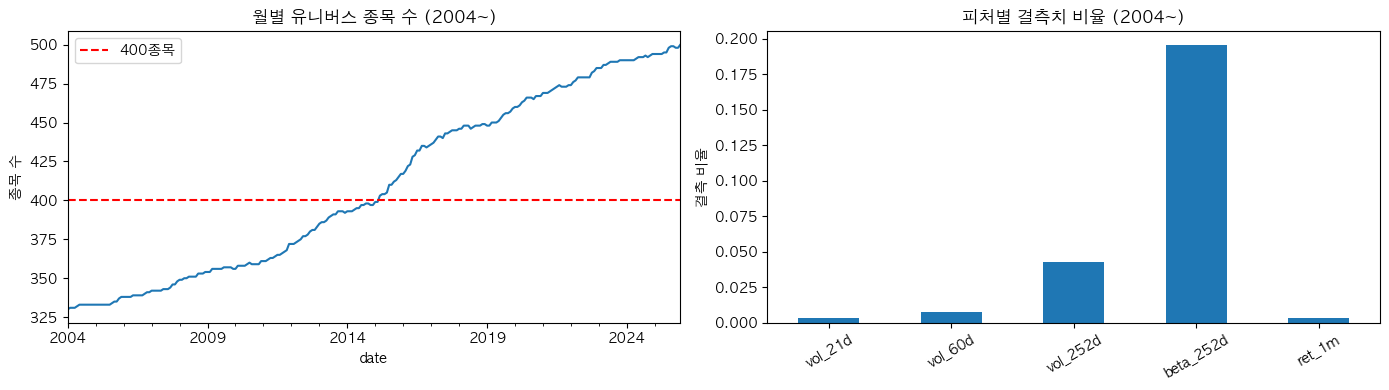

=== 2004년 이후 결측치 수 ===
vol_21d          380
vol_60d          814
vol_252d        4623
beta_252d      21141
close              0
log_mcap           0
fwd_ret_1m        15
gics_sector        0
spy_ret          330
rf_1m              0
ret_1m           381

=== 기초 통계 (2004~2026) ===
            ret_1m      vol_21d     vol_252d   beta_252d      spy_ret  \
count  107754.0000  107755.0000  103512.0000  86994.0000  107805.0000   
mean        0.0109       0.2886       0.3098      0.9979       0.0098   
std         0.0906       0.2054       0.1706      0.4108       0.0422   
min        -0.8435       0.0167       0.0905     -1.2186      -0.1652   
25%        -0.0364       0.1741       0.2073      0.7398      -0.0134   
50%         0.0114       0.2375       0.2663      0.9795       0.0151   
75%         0.0568       0.3334       0.3599      1.2295       0.0356   
max         2.4498       4.8805       2.8059      3.9243       0.1270   

             rf_1m  
count  108135.0000  
mean        0.0014 

In [16]:
import matplotlib.pyplot as plt

# 분석 기간 데이터만 사용 (PANEL_START 이후)
panel_dates = monthly_df.index.get_level_values('date')
df_plot = monthly_df[panel_dates >= PANEL_START]

# ── 1. 월별 종목 수 추이 ──────────────────────────────────
monthly_counts = df_plot.groupby(level='date').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

monthly_counts.plot(ax=axes[0], title=f'월별 유니버스 종목 수 ({PANEL_START[:4]}~)')
axes[0].axhline(400, color='r', linestyle='--', label='400종목')
axes[0].set_ylabel('종목 수')
axes[0].legend()

# ── 2. 결측치 비율 (PANEL_START 이후 기준) ───────────────
na_rate = df_plot[['vol_21d','vol_60d','vol_252d','beta_252d','ret_1m']].isna().mean()
na_rate.plot(kind='bar', ax=axes[1], title=f'피처별 결측치 비율 ({PANEL_START[:4]}~)')
axes[1].set_ylabel('결측 비율')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# ── 2-1. 결측치 수 (PANEL_START 이후) ────────────────────
print(f"=== {PANEL_START[:4]}년 이후 결측치 수 ===")
print(df_plot.isna().sum().to_string())

# ── 3. 기초 통계 (PANEL_START 이후 기준) ─────────────────
print(f"\n=== 기초 통계 ({PANEL_START[:4]}~{PRICE_END[:4]}) ===")
print(df_plot[['ret_1m','vol_21d','vol_252d','beta_252d','spy_ret','rf_1m']].describe().round(4))

# ── 4. 유니버스 → 패널 종목 수 흐름 ──────────────────────
tickers_in_panel = set(monthly_df.index.get_level_values('ticker'))
n_universe       = len(df_universe)
n_no_price       = sum(close[t].isna().all() for t in df_universe['ticker'] if t in close.columns)
n_short          = sum(1 for t in df_universe['ticker']
                       if t in close.columns and 0 < len(close[t].dropna()) < 252)
n_panel          = len(tickers_in_panel)

print(f"\n=== 유니버스 → 패널 종목 수 흐름 ===")
print(f"  유니버스 전체:       {n_universe}종목")
print(f"  가격 데이터 전무:   -{n_no_price}종목  (yfinance에 데이터 없음)")
print(f"  데이터 252일 미만:  -{n_short}종목  (상장기간 짧음)")
print(f"  최종 패널 종목 수:   {n_panel}종목")

# ── 5. Unknown 섹터 잔존 현황 ─────────────────────────────
unknown_tickers = set(df_universe.loc[df_universe['gics_sector'] == 'Unknown', 'ticker'])
n_unknown_total = len(unknown_tickers)
n_unknown_panel = len(unknown_tickers & tickers_in_panel)

print(f"\n=== Unknown 섹터 현황 ===")
print(f"  유니버스 내 Unknown:   {n_unknown_total}종목")
print(f"  패널에 잔존한 Unknown: {n_unknown_panel}종목  (가격 데이터 있어 포함)")
print(f"  필터링된 Unknown:      {n_unknown_total - n_unknown_panel}종목")

# ── 6. GOOGL/GOOG 중복 제거 확인 ─────────────────────────
print(f"\n=== 중복 제거 확인 ===")
print(f"  GOOG  포함: {'GOOG'  in tickers_in_panel}")
print(f"  GOOGL 포함: {'GOOGL' in tickers_in_panel}")
print(f"  BRK-A 포함: {'BRK-A' in tickers_in_panel}")
print(f"  BRK-B 포함: {'BRK-B' in tickers_in_panel}")

In [17]:
sizes = pd.Series({date: len(members) for date, members in sp500_membership.items()})
sizes = sizes.sort_index()
print("월별 S&P500 멤버십 크기:")
print(sizes.describe().round(0))
print(sizes.head(10))
print(sizes.tail(10))

월별 S&P500 멤버십 크기:
count    267.0
mean     508.0
std        4.0
min      503.0
25%      506.0
50%      507.0
75%      511.0
max      516.0
dtype: float64
2004-01-31    515
2004-02-29    515
2004-03-31    515
2004-04-30    515
2004-05-31    515
2004-06-30    515
2004-07-31    515
2004-08-31    515
2004-09-30    515
2004-10-31    515
dtype: int64
2025-06-30    503
2025-07-31    503
2025-08-31    503
2025-09-30    503
2025-10-31    503
2025-11-30    503
2025-12-31    503
2026-01-31    503
2026-02-28    503
2026-03-31    503
dtype: int64


In [18]:
nan_count = sum(prices_raw['Close'].isna().all())
print(f"all-NaN 티커: {nan_count}개")

all-NaN 티커: 165개
